In [ ]:
!pip install pyspark

In [ ]:
from pyspark.sql import SparkSession
# Initialize SparkSession
spark = SparkSession.builder \
 .appName("Airline delay") \
 .getOrCreate()

In [ ]:
df = spark.read.csv("/content/Airline_Delay_Cause (1).csv", header=True, inferSchema=True)
# Show the DataFrame
df.show()


+----+-----+-------+-------------+-------+--------------------+-----------+---------+----------+----------+------+-----------+----------------+-------------+------------+---------+-------------+-------------+---------+--------------+-------------------+
|year|month|carrier| carrier_name|airport|        airport_name|arr_flights|arr_del15|carrier_ct|weather_ct|nas_ct|security_ct|late_aircraft_ct|arr_cancelled|arr_diverted|arr_delay|carrier_delay|weather_delay|nas_delay|security_delay|late_aircraft_delay|
+----+-----+-------+-------------+-------+--------------------+-----------+---------+----------+----------+------+-----------+----------------+-------------+------------+---------+-------------+-------------+---------+--------------+-------------------+
|2025|    1|     G4|Allegiant Air|    ELM|Elmira/Corning, N...|         30|        0|       0.0|       0.0|   0.0|        0.0|             0.0|            0|           0|        0|            0|            0|        0|             0|     

In [ ]:
df.printSchema()

root
 |-- year: integer (nullable = true)
 |-- month: integer (nullable = true)
 |-- carrier: string (nullable = true)
 |-- carrier_name: string (nullable = true)
 |-- airport: string (nullable = true)
 |-- airport_name: string (nullable = true)
 |-- arr_flights: integer (nullable = true)
 |-- arr_del15: integer (nullable = true)
 |-- carrier_ct: double (nullable = true)
 |-- weather_ct: double (nullable = true)
 |-- nas_ct: double (nullable = true)
 |-- security_ct: double (nullable = true)
 |-- late_aircraft_ct: double (nullable = true)
 |-- arr_cancelled: integer (nullable = true)
 |-- arr_diverted: integer (nullable = true)
 |-- arr_delay: integer (nullable = true)
 |-- carrier_delay: integer (nullable = true)
 |-- weather_delay: integer (nullable = true)
 |-- nas_delay: integer (nullable = true)
 |-- security_delay: integer (nullable = true)
 |-- late_aircraft_delay: integer (nullable = true)



In [ ]:
from pyspark.sql.functions import col, when, count

#counts null in each section
null_counts = df.select([
    count(when(col(c).isNull(), c)).alias(c)
    for c in df.columns
])

null_counts.show()
# fill any numeric null with zero
df = df.fillna(0)

# fill any string null with "unknown"
df = df.fillna("Unknown")

# ensure no nulls remain
df.select([
    count(when(col(c).isNull(), c)).alias(c)
    for c in df.columns
]).show()

+----+-----+-------+------------+-------+------------+-----------+---------+----------+----------+------+-----------+----------------+-------------+------------+---------+-------------+-------------+---------+--------------+-------------------+
|year|month|carrier|carrier_name|airport|airport_name|arr_flights|arr_del15|carrier_ct|weather_ct|nas_ct|security_ct|late_aircraft_ct|arr_cancelled|arr_diverted|arr_delay|carrier_delay|weather_delay|nas_delay|security_delay|late_aircraft_delay|
+----+-----+-------+------------+-------+------------+-----------+---------+----------+----------+------+-----------+----------------+-------------+------------+---------+-------------+-------------+---------+--------------+-------------------+
|   0|    0|      0|           0|      0|           0|        657|      950|       657|       657|   657|        657|             657|          657|         657|      657|          657|          657|      657|           657|                657|
+----+-----+-------+

In [ ]:
# IMPUTATION

# replace numeric null values with 0
df = df.fillna(0)

# replace string columns with "Unknown"
df = df.fillna("Unknown")

# flights cannot be negative
df = df.withColumn(
    "arr_flights",
    when(col("arr_flights") < 0, 0).otherwise(col("arr_flights"))
)
# delays cannot exceed total flights
df= df.withColumn (
    "arr_del15",
    when(col("arr_del15") > col("arr_flights"), col("arr_flights"))
    .otherwise(col("arr_del15"))
)
#months are between 1-12
df = df.filter((col("month") >= 1) & (col("month") <= 12))

df = df.filter(col("year") >= 2000)

df.show(5)

+----+-----+-------+-------------+-------+--------------------+-----------+---------+----------+----------+------+-----------+----------------+-------------+------------+---------+-------------+-------------+---------+--------------+-------------------+
|year|month|carrier| carrier_name|airport|        airport_name|arr_flights|arr_del15|carrier_ct|weather_ct|nas_ct|security_ct|late_aircraft_ct|arr_cancelled|arr_diverted|arr_delay|carrier_delay|weather_delay|nas_delay|security_delay|late_aircraft_delay|
+----+-----+-------+-------------+-------+--------------------+-----------+---------+----------+----------+------+-----------+----------------+-------------+------------+---------+-------------+-------------+---------+--------------+-------------------+
|2025|    1|     G4|Allegiant Air|    ELM|Elmira/Corning, N...|         30|        0|       0.0|       0.0|   0.0|        0.0|             0.0|            0|           0|        0|            0|            0|        0|             0|     

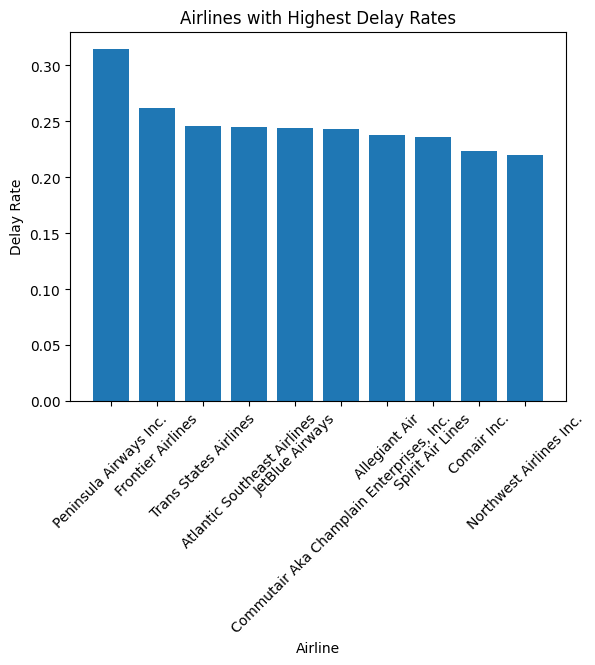

In [ ]:
import pyspark.sql.functions as F
import matplotlib.pyplot as plt

df = df.fillna(0).filter(F.col("arr_flights") > 0)


# groupBy aggregation

airline_delays = (
    df.groupBy("carrier_name")
    .agg(
        F.sum("arr_del15").alias("delayed"),
        F.sum("arr_flights").alias("flights")
    )
    .withColumn("delay_rate", F.col("delayed") / F.col("flights"))
    .orderBy(F.desc("delay_rate"))
)

# Convert small result to pandas for plotting
pdf = airline_delays.limit(10).toPandas()


# BAR CHART

plt.bar(pdf["carrier_name"], pdf["delay_rate"])
plt.title("Airlines with Highest Delay Rates")
plt.xlabel("Airline")
plt.ylabel("Delay Rate")
plt.xticks(rotation=45)
plt.show()


In [ ]:

from pyspark.sql import SparkSession, functions as F
import matplotlib.pyplot as plt
import pandas as pd

spark = SparkSession.builder.appName("FlightDelayTrend").getOrCreate()

# Load CSV
df = spark.read.option("header", True).option("inferSchema", True) \
    .csv("/content/Airline_Delay_Cause (1).csv")

# Basic cleaning
df = df.fillna(0).filter(F.col("arr_flights") > 0)

# AGGREGATE IN SPARK

delay_trend = (
    df.groupBy("year", "month")
    .agg(
        F.sum("arr_del15").alias("delayed"),
        F.sum("arr_flights").alias("flights")
    )
    .withColumn("delay_rate", F.col("delayed") / F.col("flights"))
    .orderBy("year", "month")
)


# CONVERT SMALL RESULT TO PANDAS

pdf = delay_trend.toPandas()

# Create date column for plotting
pdf["date"] = pd.to_datetime(
    pdf["year"].astype(str) + "-" + pdf["month"].astype(str) + "-01"
)


# LINE CHART

plt.plot(pdf["date"], pdf["delay_rate"])
plt.title("Overall Flight Delay Rate Over Time")
plt.xlabel("Year-Month")
plt.ylabel("arr_del15 / arr_flights")
plt.xticks(rotation=45)
plt.show()

In [ ]:
from pyspark.sql import SparkSession, functions as F
import matplotlib.pyplot as plt

spark = SparkSession.builder.appName("AirlineDelayRate").getOrCreate()

# Load CSV
df = spark.read.option("header", True).option("inferSchema", True) \
    .csv("/content/Airline_Delay_Cause (1).csv")

# Basic cleaning
df = df.fillna(0).filter(F.col("arr_flights") > 0)


# AGGREGATE IN SPARK

airline_delay_rate = (
    df.groupBy("carrier_name")
    .agg(
        F.sum("arr_del15").alias("delayed"),
        F.sum("arr_flights").alias("flights")
    )
    .withColumn("delay_rate", F.col("delayed") / F.col("flights"))
    .orderBy(F.desc("delay_rate"))
)


# CONVERT TO PANDAS

pdf = airline_delay_rate.limit(10).toPandas()


# BAR CHART

plt.bar(pdf["carrier_name"], pdf["delay_rate"])
plt.title("Airlines with Highest Delay Percentage")
plt.xlabel("Carrier Name")
plt.ylabel("Average Delay Rate")
plt.xticks(rotation=45)
plt.show()

In [ ]:
from pyspark.sql import SparkSession, functions as F
import matplotlib.pyplot as plt

spark = SparkSession.builder.appName("AirportDelayScatter").getOrCreate()

# Load CSV
df = spark.read.option("header", True).option("inferSchema", True) \
    .csv("/content/Airline_Delay_Cause (1).csv")

# Basic cleaning
df = df.fillna(0).filter(F.col("arr_flights") > 0)


# AGGREGATE IN SPARK

airport_delay_rate = (
    df.groupBy("airport")
    .agg(
        F.sum("arr_del15").alias("delayed"),
        F.sum("arr_flights").alias("flights")
    )
    .withColumn("delay_rate", F.col("delayed") / F.col("flights"))
    .orderBy(F.desc("delay_rate"))
)

# Convert small result to pandas
pdf = airport_delay_rate.limit(100).toPandas()


# SCATTER CHART

plt.scatter(pdf["flights"], pdf["delay_rate"])
plt.title("Airport Delay Rate vs Total Flights")
plt.xlabel("Total Flights")
plt.ylabel("Delay Rate")
plt.show()

In [ ]:
from pyspark.sql import SparkSession, functions as F
import matplotlib.pyplot as plt

spark = SparkSession.builder.appName("DelayCauses").getOrCreate()

# Load CSV
df = spark.read.option("header", True).option("inferSchema", True) \
    .csv("/content/Airline_Delay_Cause (1).csv")

# Basic cleaning
df = df.fillna(0)

# Delay cause columns
causes = ["carrier_ct", "weather_ct", "nas_ct", "security_ct", "late_aircraft_ct"]


# AGGREGATE IN SPARK

cause_year = df.groupBy("year").agg(*[F.sum(c).alias(c) for c in causes])

# total delays per year
cause_year = cause_year.withColumn(
    "total",
    sum(F.col(c) for c in causes)
)

# convert to percentages
for c in causes:
    cause_year = cause_year.withColumn(c, F.col(c) / F.col("total"))

cause_year = cause_year.orderBy("year")


# CONVERT TO PANDAS

pdf = cause_year.toPandas()


# STACKED BAR CHART

bottom = None

for c in causes:
    if bottom is None:
        plt.bar(pdf["year"], pdf[c], label=c)
        bottom = pdf[c]
    else:
        plt.bar(pdf["year"], pdf[c], bottom=bottom, label=c)
        bottom = bottom + pdf[c]

plt.title("Delay Cause Distribution by Year")
plt.xlabel("Year")
plt.ylabel("Percentage")
plt.legend()
plt.show()

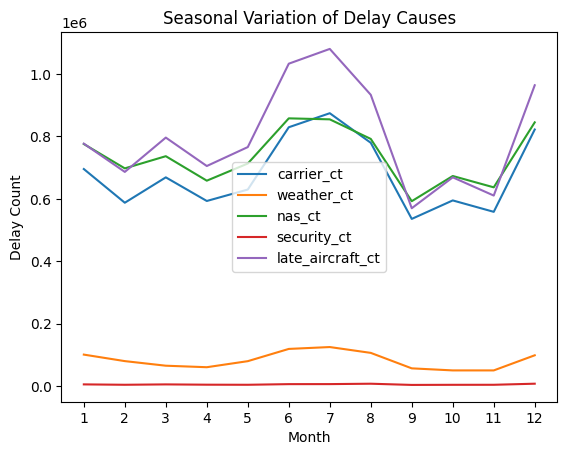

In [ ]:
from pyspark.sql import SparkSession, functions as F
import matplotlib.pyplot as plt

spark = SparkSession.builder.appName("SeasonalCauses").getOrCreate()

# Load CSV
df = spark.read.option("header", True).option("inferSchema", True) \
    .csv("/content/Airline_Delay_Cause (1).csv")

# Basic cleaning
df = df.fillna(0)

causes = ["carrier_ct", "weather_ct", "nas_ct", "security_ct", "late_aircraft_ct"]

# -------------------------
# AGGREGATE IN SPARK
# -------------------------
monthly_causes = (
    df.groupBy("month")
    .agg(*[F.sum(c).alias(c) for c in causes])
    .orderBy("month")
)

# -------------------------
# CONVERT TO PANDAS
# -------------------------
pdf = monthly_causes.toPandas()

# -------------------------
# MULTI-LINE CHART
# -------------------------
for c in causes:
    plt.plot(pdf["month"], pdf[c], label=c)

plt.title("Seasonal Variation of Delay Causes")
plt.xlabel("Month")
plt.ylabel("Delay Count")
plt.xticks(range(1, 13))
plt.legend()
plt.show()








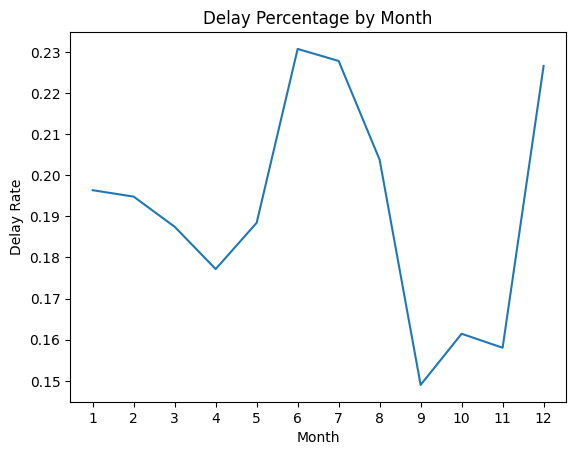

Highest delay month:
+-----+-------+--------+------------------+
|month|delayed| flights|        delay_rate|
+-----+-------+--------+------------------+
|    6|2845053|12331062|0.2307224633206775|
+-----+-------+--------+------------------+

Lowest delay month:
+-----+-------+--------+-------------------+
|month|delayed| flights|         delay_rate|
+-----+-------+--------+-------------------+
|    9|1759080|11804903|0.14901266024803422|
+-----+-------+--------+-------------------+



In [ ]:
from pyspark.sql import SparkSession, functions as F
import matplotlib.pyplot as plt

spark = SparkSession.builder.appName("MonthlyDelayRates").getOrCreate()

# Load CSV
df = spark.read.option("header", True).option("inferSchema", True) \
    .csv("/content/Airline_Delay_Cause (1).csv")

# Basic cleaning
df = df.fillna(0).filter(F.col("arr_flights") > 0)

# -------------------------
# AGGREGATE IN SPARK
# -------------------------
monthly_delay = (
    df.groupBy("month")
    .agg(
        F.sum("arr_del15").alias("delayed"),
        F.sum("arr_flights").alias("flights")
    )
    .withColumn("delay_rate", F.col("delayed") / F.col("flights"))
    .orderBy("month")
)

# -------------------------
# CONVERT TO PANDAS
# -------------------------
pdf = monthly_delay.toPandas()

# -------------------------
# LINE CHART
# -------------------------
plt.plot(pdf["month"], pdf["delay_rate"])
plt.title("Delay Percentage by Month")
plt.xlabel("Month")
plt.ylabel("Delay Rate")
plt.xticks(range(1, 13))
plt.show()

# -------------------------
# HIGHEST AND LOWEST MONTHS
# -------------------------
highest = monthly_delay.orderBy(F.desc("delay_rate")).limit(1)
lowest = monthly_delay.orderBy("delay_rate").limit(1)

print("Highest delay month:")
highest.show()

print("Lowest delay month:")
lowest.show()


In [ ]:
pip install nbconvert

In [ ]:
!jupyter nbconvert --to html "/content/WEEK2_GROUP10_OTERI_ORITSEJOLOMISAN_(AIRLINE_DATASET).ipynb"

[NbConvertApp] Converting notebook /content/WEEK2_GROUP10_OTERI_ORITSEJOLOMISAN_(AIRLINE_DATASET).ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 3 image(s).
[NbConvertApp] Writing 541390 bytes to /content/WEEK2_GROUP10_OTERI_ORITSEJOLOMISAN_(AIRLINE_DATASET).html
